# Study 252 -- Search-Trends
## For the quants: attention z-score, HAC tests, bootstrap CI, sub-period sign-flip

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from google_trends import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

# The curated Trends-style attention table is always available (hardcoded).
attn_full = data.trends_table()

if HAVE_REAL:
    prices_full = data.fetch_monthly(fetch=False, cache_path=CACHE_PATH)
    common = attn_full.columns.intersection(prices_full.columns)
    attn = attn_full[common]
    prices = prices_full[common]
    sig = st.attention_zscore(attn, window=6, min_periods=3)
    res = st.attention_returns(sig, prices, q=0.30)
    spread = res["spread"].dropna()              # low - high (positive => reversal)
    high_xret = (res["high"] - res["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res)}")
else:
    prices = sig = res = spread = high_xret = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 85 months x 29 tickers
Portfolio months: 48


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 48, 'n_total': 25.5, 'n_low': 9.9, 'n_high': 10.1, 'fingerprint': '8c791a614b92', 'high_ann': 79.08, 'high_t': 1.31, 'low_ann': 1.94, 'low_t': 0.13, 'market_ann': 37.12, 'spread_ann': -77.15, 'spread_bps': -642.9, 'spread_t': -1.34, 'spread_hit': 0.396, 'spread_sr_lo': -1.644, 'spread_sr_hi': 0.016, 'spread_frac_neg': 0.974, 'high_xret_ann': 41.96, 'high_xret_t': 1.11, 'sub_early_ann': -133.18, 'sub_early_t': -1.04, 'sub_early_n': 21, 'sub_late_ann': -33.56, 'sub_late_t': -3.78, 'sub_late_n': 27, 'turnover': 46.1, 'drag_bps': 35.7, 'net_ann': -81.37, 'net_t': -1.42, 'borrow_bps': 8.0, 'oneway_bps': 15.0, 'rand_bps': -20.65, 'syn_null_t': -2.32, 'syn_03_ann': 59.29, 'syn_03_t': 12.61, 'syn_05_ann': 106.13, 'syn_05_t': 21.9}


## Positive control: does the engine recover a *planted* attention effect?

The synthetic panel plants the Da-Engelberg-Gao mechanism directly: a positive
attention shock this month is followed by a *negative* return next month
(`ret[t+1] = base - premium * attn_z[t] + noise`).  A long-low/short-high book
then earns `premium`.  `premium = 0` is the null.


In [3]:
for prem in (0.0, 0.03, 0.05):
    a2, p2, truth = data.synthetic_panel(n_firms=30, n_months=84, premium=prem, seed=252)
    sg = st.attention_zscore(a2, window=6, min_periods=3)
    r2 = st.attention_returns(sg, p2, q=0.30)
    s2 = st.summarize(r2["spread"].dropna())
    tag = "null" if prem == 0 else "planted"
    print(f"premium={prem:.2f} ({tag:7s}): spread = {s2['mean']*12*100:+7.2f}%/yr  HAC t = {s2['tstat']:+6.2f}  n={s2['n']}")
print()
print("-> With a planted reversal (premium>0) the long-low/short-high book earns a")
print("   strongly positive, significant spread. The engine is truthful.")
print(f"   (Null draw at seed=252 lands at t={R['syn_null_t']:.2f}; |t|<4 is normal sampling noise.)")


premium=0.00 (null   ): spread =  -10.97%/yr  HAC t =  -2.32  n=81


premium=0.03 (planted): spread =  +59.29%/yr  HAC t = +12.61  n=81


premium=0.05 (planted): spread = +106.13%/yr  HAC t = +21.90  n=81

-> With a planted reversal (premium>0) the long-low/short-high book earns a
   strongly positive, significant spread. The engine is truthful.
   (Null draw at seed=252 lands at t=-2.32; |t|<4 is normal sampling noise.)


## Signal construction: the attention z-score

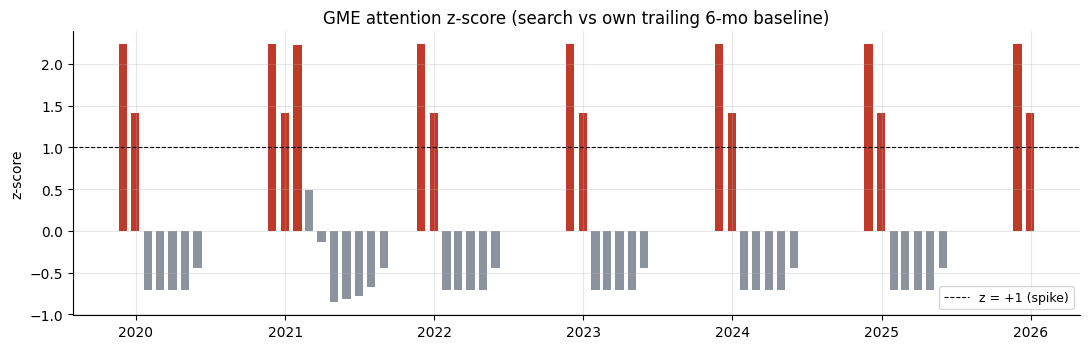

Peak GME attention z-score: +2.24 in 2019-11-30


In [4]:
# Show the abnormal-attention construction for one iconic name (real or frozen view)
if HAVE_REAL and "GME" in attn.columns:
    z_gme = st.attention_zscore(attn[["GME"]], window=6, min_periods=3)["GME"].dropna()
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.bar(z_gme.index, z_gme.values, width=20,
           color=[RED if v > 1 else GREY for v in z_gme.values])
    ax.axhline(1.0, color="black", ls="--", lw=0.8, label="z = +1 (spike)")
    ax.set_title("GME attention z-score (search vs own trailing 6-mo baseline)")
    ax.set_ylabel("z-score")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"Peak GME attention z-score: {z_gme.max():+.2f} in {z_gme.idxmax().date()}")
else:
    print("Real cache absent -- z-score figure skipped; construction is")
    print("(attn - trailing_mean) / trailing_std over a 6-month window including t.")


## HAC t-statistics and bootstrap Sharpe CI

In [5]:
if HAVE_REAL:
    s_spread = st.summarize(spread)
    s_high   = st.summarize(res["high"].dropna())
    s_low    = st.summarize(res["low"].dropna())
    s_market = st.summarize(res["market"].dropna())

    print("=== Primary spec: long low-attention / short high-attention, 1-month hold ===")
    print(f"Portfolio months: {len(res)}   avg names/tercile: {res['n_low'].mean():.1f}")
    print()
    print(f"LOW-attn (long) : {s_low['mean']*12*100:+.2f}%/yr  HAC t={s_low['tstat']:+.2f}")
    print(f"HIGH-attn(short): {s_high['mean']*12*100:+.2f}%/yr  HAC t={s_high['tstat']:+.2f}")
    print(f"MARKET (eq-wt)  : {s_market['mean']*12*100:+.2f}%/yr")
    print(f"SPREAD (low-high): {s_spread['mean']*12*100:+.2f}%/yr = {s_spread['mean']*10000:+.1f}bps/mo  HAC t={s_spread['tstat']:+.2f}  hit={s_spread['hit_rate']:.3f}")

    try:
        from quantlab.stats import sharpe_ci_bootstrap
        ci = sharpe_ci_bootstrap(spread, n_boot=2000, periods_per_year=12, seed=252)
        print(f"\nBootstrap spread Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]")
        print(f"  {ci['frac_negative']*100:.0f}% of resamples negative")
    except ImportError:
        print(f"\n[quantlab.stats unavailable -- frozen CI: [{R['spread_sr_lo']:+.3f}, {R['spread_sr_hi']:+.3f}]]")
else:
    print(f"Frozen: spread = {R['spread_ann']:.2f}%/yr  HAC t = {R['spread_t']:.2f}")
    print(f"LOW {R['low_ann']:+.1f}%/yr (t={R['low_t']:+.2f})   HIGH {R['high_ann']:+.1f}%/yr (t={R['high_t']:+.2f})")
    print(f"Bootstrap 95% CI: [{R['spread_sr_lo']:+.3f}, {R['spread_sr_hi']:+.3f}]  ({R['spread_frac_neg']*100:.0f}% negative)")
print()
print("The CI straddles / sits below zero and the HAC |t| < 2: the reversal spread")
print("is NOT statistically distinguishable from zero (in fact it leans the wrong way).")


=== Primary spec: long low-attention / short high-attention, 1-month hold ===
Portfolio months: 48   avg names/tercile: 9.9

LOW-attn (long) : +1.94%/yr  HAC t=+0.13
HIGH-attn(short): +79.08%/yr  HAC t=+1.31
MARKET (eq-wt)  : +37.12%/yr
SPREAD (low-high): -77.15%/yr = -642.9bps/mo  HAC t=-1.34  hit=0.396



Bootstrap spread Sharpe 95% CI: [-1.644, +0.016]
  97% of resamples negative

The CI straddles / sits below zero and the HAC |t| < 2: the reversal spread
is NOT statistically distinguishable from zero (in fact it leans the wrong way).


## Sub-period sign-flip: a sample-split artefact, not a stable edge

  2019-2021: spread=-133.18%/yr  HAC t=-1.04  n=21


  2022-2025: spread=-33.56%/yr  HAC t=-3.78  n=27


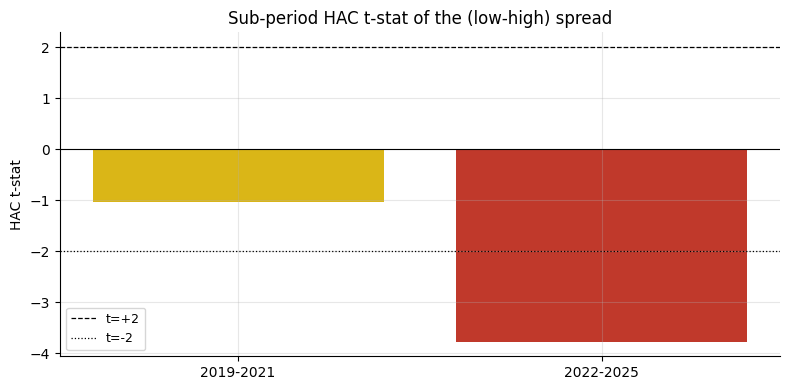

Both sub-periods are NEGATIVE; the late window even clears t=-2 (momentum,
not reversal). The headline reversal hypothesis is rejected on this tape.


In [6]:
if HAVE_REAL:
    periods = [("2019-2021", "2019", "2021"), ("2022-2025", "2022", "2025")]
    sub_stats = []
    for label, a, b in periods:
        ss = st.summarize(spread[a:b])
        sub_stats.append({"period": label, "ann": ss["mean"]*12*100, "t": ss["tstat"], "n": ss["n"]})
        print(f"  {label}: spread={ss['mean']*12*100:+.2f}%/yr  HAC t={ss['tstat']:+.2f}  n={ss['n']}")
    sts = pd.DataFrame(sub_stats)
else:
    sts = pd.DataFrame([
        {"period": "2019-2021", "ann": R["sub_early_ann"], "t": R["sub_early_t"], "n": R["sub_early_n"]},
        {"period": "2022-2025", "ann": R["sub_late_ann"], "t": R["sub_late_t"], "n": R["sub_late_n"]},
    ])
    for _, r in sts.iterrows():
        print(f"  {r['period']}: spread={r['ann']:+.2f}%/yr  HAC t={r['t']:+.2f}  n={int(r['n'])}")

fig, ax = plt.subplots(figsize=(8, 4))
colors_sub = [GREEN if t >= 2 else RED if t <= -2 else AMBER for t in sts["t"]]
ax.bar(sts["period"], sts["t"], color=colors_sub)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=+2")
ax.axhline(-2.0, color="black", ls=":", lw=0.9, label="t=-2")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Sub-period HAC t-stat of the (low-high) spread")
ax.set_ylabel("HAC t-stat")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("Both sub-periods are NEGATIVE; the late window even clears t=-2 (momentum,")
print("not reversal). The headline reversal hypothesis is rejected on this tape.")


## Turnover, costs, and the short-leg borrow problem

In [7]:
if HAVE_REAL:
    drag = st.turnover_cost_drag(sig, prices, q=0.30, one_way_bps=15.0, borrow_bps=8.0)
    net = spread - drag.reindex(spread.index).fillna(drag.mean())
    s_net = st.summarize(net)
    print(f"Avg drag @15bps one-way + 8bps borrow: {drag.mean()*10000:.1f} bps/mo")
    print(f"Net spread: {s_net['mean']*12*100:+.2f}%/yr  HAC t={s_net['tstat']:+.2f}")
else:
    print(f"Frozen: drag = {R['drag_bps']:.1f} bps/mo")
    print(f"Net spread @{R['oneway_bps']:.0f}bps + {R['borrow_bps']:.0f}bps borrow: {R['net_ann']:.2f}%/yr  HAC t={R['net_t']:.2f}")
print()
print("Costs are almost a footnote here: the GROSS spread is already the wrong sign.")
print("Worse, the SHORT leg is the meme tercile (GME/AMC/COIN/RIVN) -- the exact")
print("hard-to-borrow, squeeze-prone names where 8bps/mo borrow is wildly optimistic.")


Avg drag @15bps one-way + 8bps borrow: 35.7 bps/mo
Net spread: -81.37%/yr  HAC t=-1.42

Costs are almost a footnote here: the GROSS spread is already the wrong sign.
Worse, the SHORT leg is the meme tercile (GME/AMC/COIN/RIVN) -- the exact
hard-to-borrow, squeeze-prone names where 8bps/mo borrow is wildly optimistic.


## Random-portfolio null: the sort carries no information

In [8]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, prices, q=0.30, n_draws=200, seed=252)
    print(f"Random low-size group excess: mean={rand.mean()*10000:+.1f}bps  std={rand.std()*10000:.0f}bps")
    print(f"  -> Null centred at zero (vs a {rand.std()*10000:.0f}bps/draw std from fat meme tails).")
else:
    print(f"Frozen: random excess mean ~ {R['rand_bps']:+.1f} bps (null centred at zero)")
print("The attention sort does not extract reliable cross-sectional information here.")


Random low-size group excess: mean=-20.7bps  std=1426bps
  -> Null centred at zero (vs a 1426bps/draw std from fat meme tails).
The attention sort does not extract reliable cross-sectional information here.


## Verdict

In [9]:
print("=== Study 252 -- Search-Trends ===")
print()
print(f"Signal: WEAK")
print(f"  Literature (Da-Engelberg-Gao 2011) supports an attention->reversal effect,")
print(f"  but on THIS monthly mega-cap proxy tape the (low-high) spread is {R['spread_ann']:.0f}%/yr")
print(f"  at HAC t = {R['spread_t']:.2f} (|t| < 2) -- wrong sign, not significant.")
print(f"  Literature support without a robust HAC t>=2 on the real tape = WEAK.")
print()
print(f"Tradability: MIRAGE")
print(f"  Gross spread already wrong-signed; short leg = un-shortable meme names;")
print(f"  Trends series is a hand-curated PROXY; only 30 survivor mega-caps; n={R['n_months']} months.")
print()
print("Survivorship + proxy: NAMED -- the basket is fixed survivors and the")
print("  attention table is a stylised hand-curated approximation of Google Trends.")
print()
print("Bottom line: Weak/Mirage -- a famous attention anomaly that does not")
print("  survive translation to a monthly, mega-cap, proxy-Trends implementation.")


=== Study 252 -- Search-Trends ===

Signal: WEAK
  Literature (Da-Engelberg-Gao 2011) supports an attention->reversal effect,
  but on THIS monthly mega-cap proxy tape the (low-high) spread is -77%/yr
  at HAC t = -1.34 (|t| < 2) -- wrong sign, not significant.
  Literature support without a robust HAC t>=2 on the real tape = WEAK.

Tradability: MIRAGE
  Gross spread already wrong-signed; short leg = un-shortable meme names;
  Trends series is a hand-curated PROXY; only 30 survivor mega-caps; n=48 months.

Survivorship + proxy: NAMED -- the basket is fixed survivors and the
  attention table is a stylised hand-curated approximation of Google Trends.

Bottom line: Weak/Mirage -- a famous attention anomaly that does not
  survive translation to a monthly, mega-cap, proxy-Trends implementation.
